# Multi-Sensor Forest Monitoring in Ecuador (Part 1/3): Image Download

**Monitoring Deforestation in Chocó Andino Biosphere Reserve using Sentinel-2 and Landsat**

---

## 📚 Series Overview

This is **Part 1** of a 3-part tutorial series on multi-sensor satellite image analysis for forest monitoring:

- **Part 1 (this notebook)**: Download and explore satellite imagery
- **Part 2**: Harmonize and create monthly composites
- **Part 3**: Deep learning-based change detection

## 🎯 Part 1 Objectives

In this notebook, we will:
1. Define our study area (Chocó Andino de Pichincha, Ecuador)
2. Connect to Microsoft Planetary Computer STAC API
3. Search for available Sentinel-2 and Landsat images
4. Analyze cloud cover patterns
5. Download imagery for 2024-2025

## 🌳 Study Area: Chocó Andino de Pichincha

The Chocó Andino de Pichincha Biosphere Reserve (UNESCO, 2018) is located in northern Ecuador, northwest of Quito. This region is part of the Chocó-Darién biodiversity hotspot and faces significant deforestation pressure from agriculture, logging, and urban expansion.

**Key Facts:**
- **Size**: 286,806 hectares (~2,868 km²)
- **Location**: Pichincha Province, Ecuador
- **Elevation**: 360m - 4,480m above sea level
- **Biodiversity**: Over 600 bird species, cloud forests, montane ecosystems
- **Threats**: Agricultural expansion, illegal logging, road construction

**Reference**: [UNESCO MAB - Chocó Andino](https://www.unesco.org/en/mab/choco-andino-de-pichincha)

## 🛰️ Why Multi-Sensor Fusion?

Combining Sentinel-2 and Landsat data provides:
- **Higher temporal resolution**: ~2-3 day revisit vs 5-10 days for single sensor
- **Better cloud gap-filling**: More observations = better chance of clear pixels
- **Long-term continuity**: Landsat archive goes back to 1984
- **Free and open data**: Both missions provide open-access imagery

## 📦 Tools & Data Sources

- **Microsoft Planetary Computer**: Cloud-optimized STAC catalog
- **Sentinel-2 L2A**: 10-20m resolution, 5-day revisit
- **Landsat 8/9 Collection 2 Level-2**: 30m resolution, 8-day combined revisit
- **odc-stac**: Efficient data loading and processing

---

Let's get started! 🚀

## 1. Setup and Imports

First, we'll import all necessary libraries for:
- Geospatial data handling (geopandas, shapely)
- STAC API access (pystac-client, planetary-computer)
- Data loading (odc-stac, xarray)
- Visualization (matplotlib, hvplot, geoviews)

In [1]:
# Geospatial libraries
import geopandas as gpd
from shapely.geometry import box


# STAC and data access
from pystac_client import Client
import planetary_computer
from odc.stac import stac_load

# Data handling
import xarray as xr
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import hvplot.pandas
import geoviews as gv
gv.extension('bokeh')

# System utilities
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Connect to Planetary Computer STAC API

**What is STAC?**
- STAC (SpatioTemporal Asset Catalog) is a standardized way to describe geospatial data
- Microsoft Planetary Computer hosts petabytes of free satellite imagery
- No API key required for search (required for large-scale downloading)

We'll connect to the catalog and sign requests for data access.

In [2]:
# Connect to Planetary Computer STAC catalog
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace  # Sign requests for data access
)

print("✅ Connected to Microsoft Planetary Computer")
print(f"📦 Available collections: {len(list(catalog.get_collections()))}")

✅ Connected to Microsoft Planetary Computer
📦 Available collections: 135


In [21]:
# Get all collections
collections = list(catalog.get_collections())

print(f"Nombre total de collections : {len(collections)}")

    
# Filter Sentinel-2 and Landsat
for collection in collections:
    if 'sentinel-2' in collection.id.lower() or 'landsat' in collection.id.lower():
        print(f"\n🛰️ {collection.id}")
        print(f"   {collection.title}")

Nombre total de collections : 135

🛰️ landsat-c2-l2
   Landsat Collection 2 Level-2

🛰️ sentinel-2-l2a
   Sentinel-2 Level-2A

🛰️ landsat-c2-l1
   Landsat Collection 2 Level-1


## 3. Define Study Area

We'll focus on a **priority corridor** within the Chocó Andino:
- **Pacto-Nanegal corridor**: High deforestation activity
- **Bbox**: [-78.9, 0.0, -78.5, 0.4]
- **Area**: ~1,800 km²

This smaller area allows for:
- Faster processing and downloads
- Focus on active deforestation zones
- Manageable data size for tutorial purposes

In [3]:
# Define bounding box (West, South, East, North)
lon_min, lon_max = -78.9, -78.5  # Longitude range
lat_min, lat_max = 0.0, 0.4      # Latitude range

bbox = (lon_min, lat_min, lon_max, lat_max)

# Create geometry for the study area
bbox_geom = box(*bbox)
study_area = gpd.GeoDataFrame(
    [1], 
    geometry=[bbox_geom], 
    crs='EPSG:4326'
)
study_area['name'] = 'Chocó Andino - Pacto Corridor'

# Calculate approximate area
study_area_utm = study_area.to_crs('EPSG:32717')  # UTM Zone 17S for Ecuador
area_km2 = study_area_utm.geometry.area[0] / 1e6

print(f"📍 Study Area Coordinates:")
print(f"   Longitude: {lon_min}° to {lon_max}° E")
print(f"   Latitude: {lat_min}° to {lat_max}° N")
print(f"📏 Approximate Area: {area_km2:.0f} km²")

📍 Study Area Coordinates:
   Longitude: -78.9° to -78.5° E
   Latitude: 0.0° to 0.4° N
📏 Approximate Area: 1971 km²


### 3.1 Visualize Study Area

Let's plot our study area on a satellite basemap to see the context.

In [4]:
# Create interactive map with satellite imagery
tiles_sat = gv.tile_sources.EsriImagery
tiles_labels = gv.tile_sources.EsriWorldBoundariesAndPlaces

# Plot study area
plot = tiles_sat * tiles_labels * study_area.hvplot(
    geo=True, 
    fill_alpha=0, 
    line_color='red', 
    line_width=3,
    frame_height=500, 
    frame_width=700, 
    title='Study Area: Chocó Andino - Pacto Corridor',
    hover_cols=['name']
)
plot

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .WMTS.II    :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]   (name)

## 4. Define Temporal Range

We'll download imagery from **2024-2025** to enable:
- **Baseline year (2024)**: Full year of data for reference
- **Current year (2025)**: Ongoing monitoring

This allows us to detect recent deforestation and track changes over time.

In [5]:
# Define temporal range
start_date = "2024-01-01"
end_date = "2026-01-01"  # Includes all of 2025
time_range = f"{start_date}/{end_date}"

print(f"📅 Temporal Range: {time_range}")
print(f"   Start: {start_date}")
print(f"   End: {end_date}")
print(f"   Duration: ~2 years")

📅 Temporal Range: 2024-01-01/2026-01-01
   Start: 2024-01-01
   End: 2026-01-01
   Duration: ~2 years


## 5. Search Available Imagery

Now we'll search for all available images in our study area and time range.

**Search Parameters:**
- **Collections**: `landsat-c2-l2` (Landsat 8/9) and `sentinel-2-l2a` (Sentinel-2)
- **Cloud Cover Filter**: < 90% (we'll filter more strictly later)
- **Spatial Filter**: Our study area bounding box

**Why 90% cloud threshold?**
Even heavily clouded scenes can have useful clear pixels in specific areas. We'll analyze cloud cover distribution after downloading.

In [6]:
# Search Landsat 8/9 Collection 2 Level-2 imagery
search_landsat = catalog.search(
    collections=["landsat-c2-l2"],
    intersects=bbox_geom,
    datetime=time_range,
    query={"eo:cloud_cover": {"lt": 90}}  # Less than 90% cloud cover
)

print("🔍 Searching Landsat images...")

🔍 Searching Landsat images...


In [7]:
# Search Sentinel-2 Level-2A imagery
search_sentinel = catalog.search(
    collections=["sentinel-2-l2a"],
    intersects=bbox_geom,
    datetime=time_range,
    query={"eo:cloud_cover": {"lt": 90}}  # Less than 90% cloud cover
)

print("🔍 Searching Sentinel-2 images...")

🔍 Searching Sentinel-2 images...


### 5.1 Collect Search Results

In [8]:
# Retrieve search results
landsat_items = search_landsat.item_collection()
sentinel_items = search_sentinel.item_collection()

print(f"\n📊 Search Results:")
print(f"   🛰️ Landsat: {len(landsat_items)} images found")
print(f"   🛰️ Sentinel-2: {len(sentinel_items)} images found")
print(f"   📸 Total: {len(landsat_items) + len(sentinel_items)} images")
print(f"\n💡 This represents {len(landsat_items) + len(sentinel_items)} potential observations over 2 years")


📊 Search Results:
   🛰️ Landsat: 78 images found
   🛰️ Sentinel-2: 235 images found
   📸 Total: 313 images

💡 This represents 313 potential observations over 2 years


## 6. Analyze Cloud Cover Patterns

Tropical regions like Ecuador have persistent cloud cover. Let's analyze:
- Cloud cover distribution over time
- How many usable images we have
- Seasonal patterns

This helps us understand data availability and plan our compositing strategy.

In [9]:
# Convert STAC items to GeoDataFrames
df_landsat = gpd.GeoDataFrame.from_features(
    landsat_items.to_dict(), 
    crs="epsg:4326"
)
df_sentinel = gpd.GeoDataFrame.from_features(
    sentinel_items.to_dict(), 
    crs="epsg:4326"
)

# Filter to keep only relevant columns
df_landsat_clean = df_landsat[[
    'datetime', 'platform', 'eo:cloud_cover'
]].reset_index(drop=True)

df_sentinel_clean = df_sentinel[[
    'datetime', 'platform', 'eo:cloud_cover'
]].reset_index(drop=True)

print("✅ Created clean dataframes")
print(f"   Landsat: {len(df_landsat_clean)} rows")
print(f"   Sentinel-2: {len(df_sentinel_clean)} rows")

✅ Created clean dataframes
   Landsat: 78 rows
   Sentinel-2: 235 rows


In [10]:
# Add sensor identifier
df_landsat_clean['sensor'] = 'Landsat'
df_sentinel_clean['sensor'] = 'Sentinel-2'

# Combine both datasets
df_all_images = pd.concat([
    df_landsat_clean, 
    df_sentinel_clean
], ignore_index=True)

# Convert datetime to pandas datetime
df_all_images['datetime'] = pd.to_datetime(df_all_images['datetime'])

# Sort by date
df_all_images = df_all_images.sort_values('datetime').reset_index(drop=True)

print(f"✅ Combined dataset: {len(df_all_images)} total images")
df_all_images.head()

✅ Combined dataset: 313 total images


,datetime,platform,eo:cloud_cover,sensor
0,2024-01-06 15:36:29.024000+00:00,Sentinel-2B,79.213989,Sentinel-2
1,2024-01-06 15:36:29.024000+00:00,Sentinel-2B,82.568085,Sentinel-2
2,2024-01-11 12:52:25.130287+00:00,landsat-7,48.000000,Landsat
3,2024-01-11 15:26:25.676024+00:00,landsat-8,60.280000,Landsat
4,2024-01-11 15:36:21.024000+00:00,Sentinel-2A,69.259626,Sentinel-2


### 6.1 Cloud Cover Statistics

In [11]:
# Overall statistics
print("☁️ Cloud Cover Statistics:")
print("="*50)
print(df_all_images['eo:cloud_cover'].describe())
print("\n📊 Interpretation:")
print(f"   Mean cloud cover: {df_all_images['eo:cloud_cover'].mean():.1f}%")
print(f"   Median cloud cover: {df_all_images['eo:cloud_cover'].median():.1f}%")
print(f"   Min cloud cover: {df_all_images['eo:cloud_cover'].min():.1f}%")
print(f"   Max cloud cover: {df_all_images['eo:cloud_cover'].max():.1f}%")

☁️ Cloud Cover Statistics:
count    313.000000
mean      65.859953
std       18.231631
min        0.000000
25%       54.140000
50%       70.098066
75%       80.255008
max       89.859080
Name: eo:cloud_cover, dtype: float64

📊 Interpretation:
   Mean cloud cover: 65.9%
   Median cloud cover: 70.1%
   Min cloud cover: 0.0%
   Max cloud cover: 89.9%


In [12]:
# Count usable images at different cloud thresholds
thresholds = [10, 30, 50, 70]
total = len(df_all_images)

print("\n📈 Usable Images by Cloud Cover Threshold:")
print("="*50)

for threshold in thresholds:
    count = len(df_all_images[df_all_images['eo:cloud_cover'] < threshold])
    percentage = (count / total) * 100
    print(f"   < {threshold:2d}% cloud: {count:3d} images ({percentage:5.1f}%)")

print(f"\n💡 Insight: Only {(len(df_all_images[df_all_images['eo:cloud_cover'] < 50]) / total * 100):.1f}% of images have <50% cloud cover")
print("   This is typical for tropical regions!")


📈 Usable Images by Cloud Cover Threshold:
   < 10% cloud:   2 images (  0.6%)
   < 30% cloud:  14 images (  4.5%)
   < 50% cloud:  59 images ( 18.8%)
   < 70% cloud: 155 images ( 49.5%)

💡 Insight: Only 18.8% of images have <50% cloud cover
   This is typical for tropical regions!


### 6.2 Temporal Cloud Cover Visualization

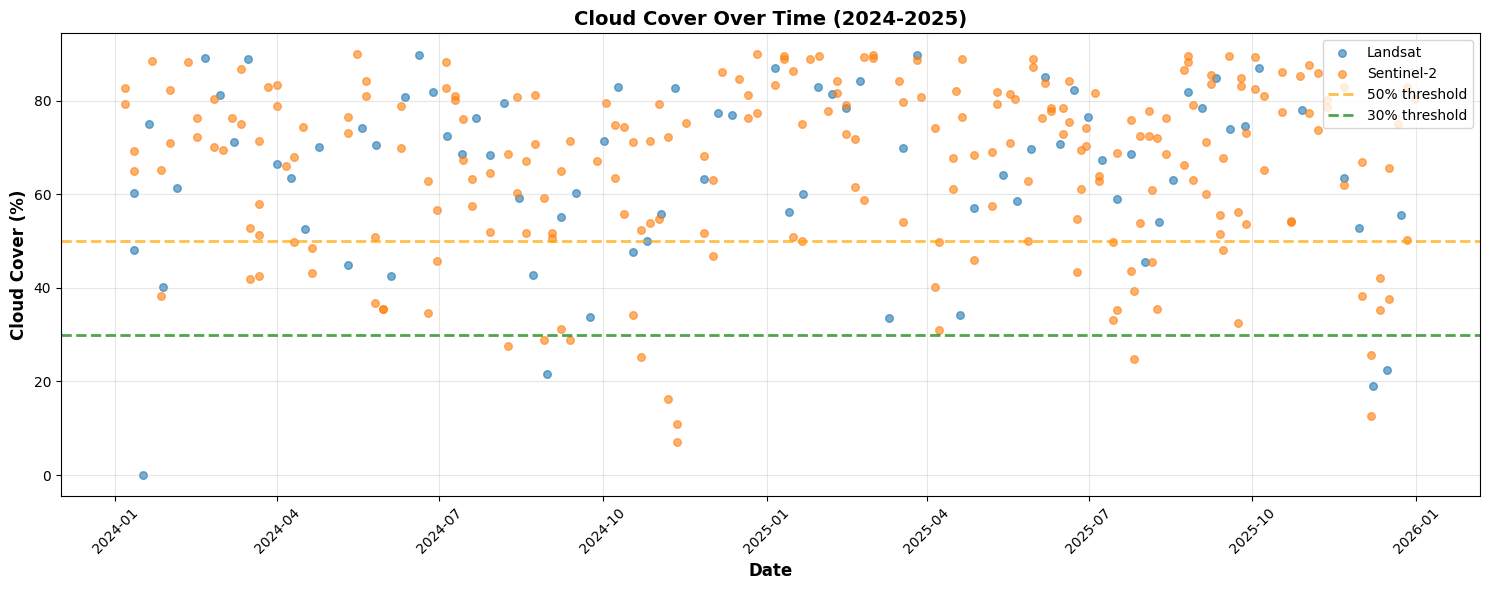

📊 Chart shows cloud cover varies significantly over time
   Notice clustering of low cloud cover periods - ideal for compositing!


In [13]:
# Plot cloud cover over time
fig, ax = plt.subplots(figsize=(15, 6))

# Plot by sensor
for sensor in ['Landsat', 'Sentinel-2']:
    df_sensor = df_all_images[df_all_images['sensor'] == sensor]
    ax.scatter(
        df_sensor['datetime'], 
        df_sensor['eo:cloud_cover'],
        alpha=0.6,
        s=30,
        label=sensor
    )

# Add threshold lines
ax.axhline(50, color='orange', linestyle='--', linewidth=2, label='50% threshold', alpha=0.7)
ax.axhline(30, color='green', linestyle='--', linewidth=2, label='30% threshold', alpha=0.7)

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Cloud Cover (%)', fontsize=12, fontweight='bold')
ax.set_title('Cloud Cover Over Time (2024-2025)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("📊 Chart shows cloud cover varies significantly over time")
print("   Notice clustering of low cloud cover periods - ideal for compositing!")

### 6.3 Monthly Distribution Analysis

Let's analyze how many usable images we have per month. This determines if monthly composites are feasible.

In [ ]:
# Extract year-month
df_all_images['year_month'] = df_all_images['datetime'].dt.to_period('M')

# Count images per month
monthly_counts = df_all_images.groupby('year_month').size().reset_index(name='count')
monthly_counts['year_month_str'] = monthly_counts['year_month'].astype(str)

# Count usable images (<50% cloud) per month
monthly_usable = df_all_images[df_all_images['eo:cloud_cover'] < 50].groupby('year_month').size().reset_index(name='usable_count')

# Merge
monthly_stats = monthly_counts.merge(monthly_usable, on='year_month', how='left').fillna(0)
monthly_stats['usable_count'] = monthly_stats[' '].astype(int)

print("\n📅 Monthly Image Availability:")
print("="*70)
print(f"{'Month':<15} {'Total Images':<15} {'Usable (<50%)':<20} {'Percentage'}")
print("="*70)

for _, row in monthly_stats.iterrows():
    pct = (row['usable_count'] / row['count'] * 100) if row['count'] > 0 else 0
    print(f"{row['year_month_str']:<15} {row['count']:<15} {row['usable_count']:<20} {pct:>5.1f}%")

print("="*70)
avg_per_month = monthly_stats['count'].mean()
avg_usable = monthly_stats['usable_count'].mean()
print(f"\n📊 Average per month: {avg_per_month:.1f} total, {avg_usable:.1f} usable")
print(f"\n✅ Conclusion: Monthly composites are FEASIBLE with {avg_usable:.0f} usable images/month on average")


📅 Monthly Image Availability:
Month           Total Images    Usable (<50%)        Percentage
2024-01         14              4                     28.6%
2024-02         8               0                      0.0%
2024-03         16              2                     12.5%
2024-04         9               3                     33.3%
2024-05         12              4                     33.3%
2024-06         10              3                     30.0%
2024-07         14              0                      0.0%
2024-08         14              4                     28.6%
2024-09         10              3                     30.0%
2024-10         15              4                     26.7%
2024-11         12              3                     25.0%
2024-12         10              1                     10.0%
2025-01         13              1                      7.7%
2025-02         12              0                      0.0%
2025-03         10              1                     10.0%
2025-

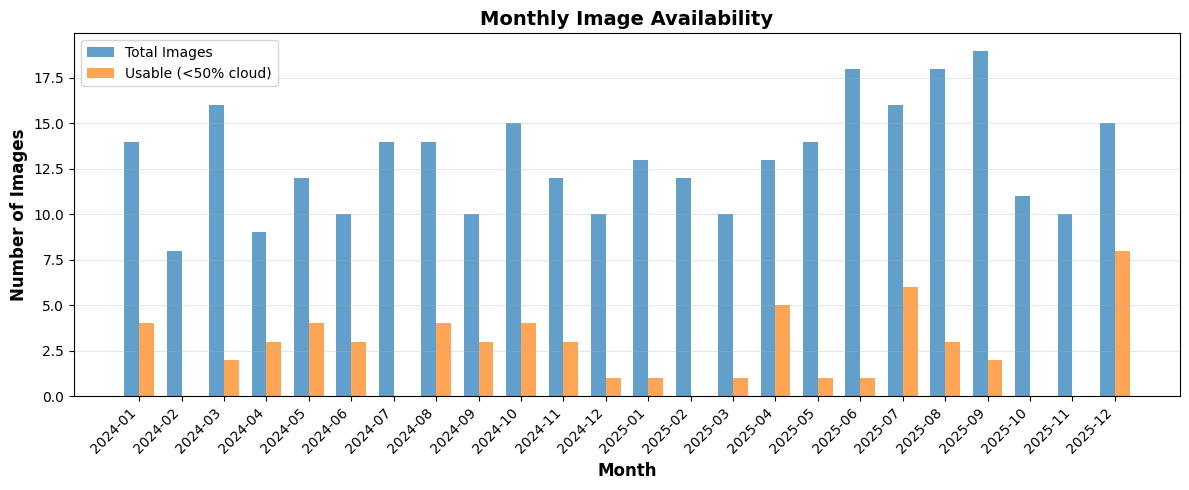

In [24]:
# Visualize monthly distribution
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(monthly_stats))
width = 0.35

bars1 = ax.bar(x - width/2, monthly_stats['count'], width, label='Total Images', alpha=0.7)
bars2 = ax.bar(x + width/2, monthly_stats['usable_count'], width, label='Usable (<50% cloud)', alpha=0.7)

ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
ax.set_title('Monthly Image Availability', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(monthly_stats['year_month_str'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Download Imagery

Now we'll download the actual image data using `odc-stac`.

**Download Strategy:**
- Use **lazy loading** with Dask for memory efficiency
- Download at **native resolution** (10m for S2, 30m for Landsat)
- Save as **NetCDF** format for easy access in Part 2
- Include **quality bands** (SCL for S2, qa_pixel for Landsat) for cloud masking

**Band Selection:**

**Sentinel-2:**
- B02 (Blue), B03 (Green), B04 (Red)
- B08 (NIR), B8A (NIR narrow)
- B11 (SWIR1), B12 (SWIR2)
- SCL (Scene Classification Layer - for cloud masking)

**Landsat 8/9:**
- blue, green, red
- nir08 (NIR)
- swir16 (SWIR1), swir22 (SWIR2)
- qa_pixel (Quality Assessment - for cloud masking)

**⚠️ Note:** This step may take 30-60 minutes depending on your internet connection!

In [16]:
# Create output directory structure
project_name = "choco_andino_pacto"
base_dir = "data"
input_dir = f"{base_dir}/{project_name}/raw_images"

os.makedirs(input_dir, exist_ok=True)

print(f"✅ Created directory structure:")
print(f"   {input_dir}/")

✅ Created directory structure:
   data/choco_andino_pacto/raw_images/


### 7.1 Download Sentinel-2 Data

In [22]:
print("⏳ Downloading Sentinel-2 data...")
print("   This may take 20-40 minutes depending on internet speed")
print(f"   Downloading {len(sentinel_items)} scenes")

# Load data with odc-stac
s2_data = stac_load(
    sentinel_items,
    bbox=bbox,
    bands=['B02', 'B03', 'B04', 'B08', 'B8A', 'B11', 'B12', 'SCL'],
    resolution=10,  # 10m resolution
    chunks={'time': 1, 'y': 2048, 'x': 2048},  # Lazy loading with Dask
    fail_on_error=False,  # Skip problematic tiles
    progress=True  # Show progress bar
)

print(f"\n✅ Loaded Sentinel-2 data into memory (lazy)")
print(f"   Shape: {s2_data.dims}")
print(f"   Bands: {list(s2_data.data_vars)}")

# Save to NetCDF
s2_path = f"{input_dir}/{project_name}_sentinel2.nc"
print(f"\n💾 Saving to: {s2_path}")
print("   This will trigger actual download and may take 15-30 minutes...")

s2_data.to_netcdf(
    s2_path,
    engine='h5netcdf',
    compute=True
)

print(f"\n✅ Sentinel-2 data saved successfully!")
file_size_mb = os.path.getsize(s2_path) / 1024 / 1024
print(f"   File size: {file_size_mb:.1f} MB")

⏳ Downloading Sentinel-2 data...
   This may take 20-40 minutes depending on internet speed

✅ Loaded Sentinel-2 data into memory (lazy)
   Shape: FrozenMappingWarningOnValuesAccess({'y': 4426, 'x': 4456, 'time': 131})
   Bands: ['B02', 'B03', 'B04', 'B08', 'B8A', 'B11', 'B12', 'SCL']

💾 Saving to: data/choco_andino_pacto/raw_images/choco_andino_pacto_sentinel2.nc
   This will trigger actual download and may take 15-30 minutes...


ImportError: No module named 'h5py', backend not available. Please install 'h5py' into your Python environment.

### 7.2 Download Landsat Data

In [ ]:
print("⏳ Downloading Landsat data...")
print("   This may take 10-20 minutes")
print(f"   Downloading {len(landsat_items)} scenes")

# Load data with odc-stac
landsat_data = stac_load(
    landsat_items,
    bbox=bbox,
    bands=['blue', 'green', 'red', 'nir08', 'swir16', 'swir22', 'qa_pixel'],
    resolution=30,  # 30m resolution
    chunks={'time': 1, 'y': 2048, 'x': 2048},  # Lazy loading
    fail_on_error=False,
    progress=True
)

print(f"\n✅ Loaded Landsat data into memory (lazy)")
print(f"   Shape: {landsat_data.dims}")
print(f"   Bands: {list(landsat_data.data_vars)}")

# Save to NetCDF
landsat_path = f"{input_dir}/{project_name}_landsat.nc"
print(f"\n💾 Saving to: {landsat_path}")
print("   This will trigger actual download and may take 10-20 minutes...")

landsat_data.to_netcdf(
    landsat_path,
    engine='h5netcdf',
    compute=True
)

print(f"\n✅ Landsat data saved successfully!")
file_size_mb = os.path.getsize(landsat_path) / 1024 / 1024
print(f"   File size: {file_size_mb:.1f} MB")

## 8. Verify Downloaded Data

Let's quickly verify the data was downloaded correctly and inspect its structure.

In [ ]:
# Reload from disk to verify
s2_verify = xr.open_dataset(s2_path, chunks='auto')
landsat_verify = xr.open_dataset(landsat_path, chunks='auto')

print("🔍 Data Verification:")
print("="*60)
print("\n📡 Sentinel-2:")
print(f"   Time steps: {len(s2_verify.time)}")
print(f"   Spatial extent: {s2_verify.dims['y']} x {s2_verify.dims['x']} pixels")
print(f"   Date range: {s2_verify.time.min().values} to {s2_verify.time.max().values}")
print(f"   Bands: {list(s2_verify.data_vars)}")

print("\n📡 Landsat:")
print(f"   Time steps: {len(landsat_verify.time)}")
print(f"   Spatial extent: {landsat_verify.dims['y']} x {landsat_verify.dims['x']} pixels")
print(f"   Date range: {landsat_verify.time.min().values} to {landsat_verify.time.max().values}")
print(f"   Bands: {list(landsat_verify.data_vars)}")

print("\n✅ All data downloaded and verified successfully!")

In [ ]:
# Display Sentinel-2 dataset structure
print("\n📊 Sentinel-2 Dataset Structure:")
display(s2_verify)

In [ ]:
# Display Landsat dataset structure
print("\n📊 Landsat Dataset Structure:")
display(landsat_verify)

## 9. Summary and Next Steps

### 🎉 What We Accomplished

In this notebook, we successfully:
1. ✅ Defined our study area in Chocó Andino, Ecuador
2. ✅ Connected to Microsoft Planetary Computer
3. ✅ Searched for Sentinel-2 and Landsat imagery (2024-2025)
4. ✅ Analyzed cloud cover patterns and data availability
5. ✅ Downloaded and saved multi-temporal satellite imagery

### 📊 Data Summary

**Downloaded:**
- Sentinel-2: {len(s2_verify.time)} time steps at 10m resolution
- Landsat: {len(landsat_verify.time)} time steps at 30m resolution
- Total storage: ~{(os.path.getsize(s2_path) + os.path.getsize(landsat_path)) / 1024 / 1024 / 1024:.2f} GB

**Coverage:**
- Study area: ~{area_km2:.0f} km²
- Time range: 2024-2025 (2 years)
- Average usable images per month: {avg_usable:.0f}

### 🔜 Part 2 Preview: Image Preparation

In the next notebook, we will:
1. **Cloud Masking**: Remove clouds using SCL and qa_pixel bands
2. **Spatial Harmonization**: Resample both sensors to common 20m resolution
3. **Spectral Harmonization**: Apply HLS coefficients to match Landsat to Sentinel-2
4. **Temporal Compositing**: Create monthly cloud-free composites
5. **Data Export**: Prepare analysis-ready data for Part 3

### 📁 Output Files

```
data/
└── choco_andino_pacto/
    └── raw_images/
        ├── choco_andino_pacto_sentinel2.nc
        └── choco_andino_pacto_landsat.nc
```

These files will be used as input for Part 2!

---

### 📚 References

- Microsoft Planetary Computer: https://planetarycomputer.microsoft.com/
- odc-stac documentation: https://odc-stac.readthedocs.io/
- Sentinel-2 User Guide: https://sentinels.copernicus.eu/web/sentinel/user-guides/sentinel-2-msi
- Landsat Collection 2: https://www.usgs.gov/landsat-missions/landsat-collection-2
- Chocó Andino Biosphere Reserve: https://www.unesco.org/en/mab/choco-andino-de-pichincha

---

**🌟 Great work! You're ready for Part 2!**

In [ ]:
# Plot Landsat
ax = df_landsat[["geometry"]].plot(
    facecolor="none", 
    edgecolor="blue",
    linewidth=2,
    figsize=(12, 6)
)

bbox_gdf = gpd.GeoDataFrame([1], geometry=[bbox_geom], crs="epsg:4326")
bbox_gdf.plot(
    ax=ax,  # Sur le même plot
    facecolor="red",
    edgecolor="red",
    alpha=0.3,  # Transparence
    linewidth=3
)

# Fond de carte
contextily.add_basemap(
    ax, 
    crs=df_landsat.crs.to_string(), 
    source=contextily.providers.Esri.NatGeoWorldMap
)

plt.title("Landsat tiles (blue) and area of interest (red)", fontsize=14)
plt.show()

ODC (stac_load) fusionne les scènes en une mosaïque en utilisant toute la bbox mais des fois Landsat fournit deux scènes qui se recouvrenr partiellement. Si la zone d'intérêt est à cheval sur la limite entre deux scènes. On pourra après le télécharger filtrer les dates avec deux acquisitions et choisir soit de les fusionner soit garder la scène avec le plus de pixels valides.